 # Social Media User Segmentation Using K-Means Clustering

## Problem Statement

.Social media platforms have millions of users.
Not all users behave the same way.



In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [28]:
df = pd.read_csv(r"C:\Users\Lenovo\Downloads\social_media_users_300 (1).csv")
df

,User_ID,Age,Daily_Time_Spent_Minutes,Posts_Per_Month,Likes_Per_Day,Comments_Per_Day,Followers_Count,Following_Count
0,1,24,234,52,132,29,7133,2564
1,2,37,135,4,284,34,11143,3576
2,3,46,139,34,387,164,17821,4731
3,4,32,62,11,137,4,12930,1297
4,5,28,181,24,183,82,15567,3952
...,...,...,...,...,...,...,...,...
295,296,45,293,29,266,19,2114,1629
296,297,39,215,54,360,4,7059,2253
297,298,40,232,41,228,36,13037,1440
298,299,22,61,50,269,165,4593,1792


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   User_ID                   300 non-null    int64
 1   Age                       300 non-null    int64
 2   Daily_Time_Spent_Minutes  300 non-null    int64
 3   Posts_Per_Month           300 non-null    int64
 4   Likes_Per_Day             300 non-null    int64
 5   Comments_Per_Day          300 non-null    int64
 6   Followers_Count           300 non-null    int64
 7   Following_Count           300 non-null    int64
dtypes: int64(8)
memory usage: 18.9 KB


In [31]:
print(df.isnull().sum())

User_ID                     0
Age                         0
Daily_Time_Spent_Minutes    0
Posts_Per_Month             0
Likes_Per_Day               0
Comments_Per_Day            0
Followers_Count             0
Following_Count             0
dtype: int64


In [32]:
df.describe(include='all')

,User_ID,Age,Daily_Time_Spent_Minutes,Posts_Per_Month,Likes_Per_Day,Comments_Per_Day,Followers_Count,Following_Count
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,33.936667,163.866667,30.273333,229.953333,101.560000,10056.486667,2426.153333
std,86.746758,9.599296,82.261730,17.686000,143.411065,57.777335,5921.809143,1434.121078
min,1.000000,18.000000,10.000000,0.000000,0.000000,0.000000,110.000000,51.000000
25%,75.750000,25.000000,104.750000,15.000000,107.500000,49.500000,4546.250000,1059.000000
50%,150.500000,34.000000,161.500000,30.500000,232.000000,103.000000,9942.500000,2396.000000
75%,225.250000,43.000000,234.250000,46.000000,349.000000,153.000000,15414.500000,3642.000000
max,300.000000,49.000000,299.000000,59.000000,492.000000,199.000000,19995.000000,4983.000000


In [33]:
print("First 5 rows:")
print(df.head())

First 5 rows:
   User_ID  Age  Daily_Time_Spent_Minutes  Posts_Per_Month  Likes_Per_Day  \
0        1   24                       234               52            132   
1        2   37                       135                4            284   
2        3   46                       139               34            387   
3        4   32                        62               11            137   
4        5   28                       181               24            183   

   Comments_Per_Day  Followers_Count  Following_Count  
0                29             7133             2564  
1                34            11143             3576  
2               164            17821             4731  
3                 4            12930             1297  
4                82            15567             3952  


In [43]:
data = df.drop("User_ID", axis=1)


In [44]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)


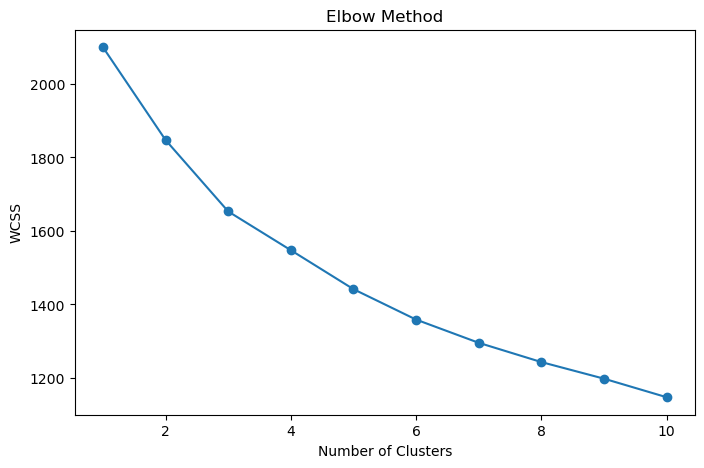

In [45]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [46]:
for i in range(2, 7):
    kmeans = KMeans(n_clusters=i, random_state=42)
    labels = kmeans.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    print(f"Silhouette Score for {i} clusters: {score}")


Silhouette Score for 2 clusters: 0.11769863546948112
Silhouette Score for 3 clusters: 0.11697004170036047
Silhouette Score for 4 clusters: 0.1101189317393088
Silhouette Score for 5 clusters: 0.11451702242936257
Silhouette Score for 6 clusters: 0.11834370951893168


In [47]:
kmeans = KMeans(n_clusters=4, random_state=42)
df["Cluster"] = kmeans.fit_predict(scaled_data)

print("\nCluster Counts:")
print(df["Cluster"].value_counts())



Cluster Counts:
Cluster
2    91
0    77
1    75
3    57
Name: count, dtype: int64


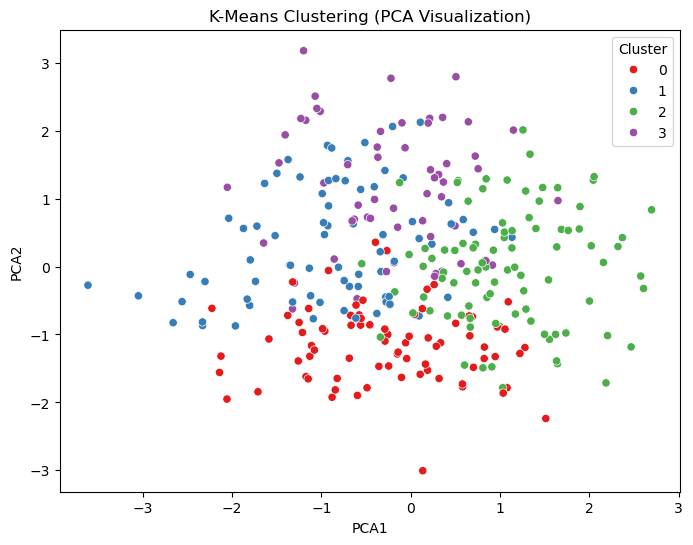

In [48]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

df["PCA1"] = pca_data[:,0]
df["PCA2"] = pca_data[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(x="PCA1", y="PCA2", hue="Cluster", data=df, palette="Set1")
plt.title("K-Means Clustering (PCA Visualization)")
plt.show()

In [49]:
cluster_summary = df.groupby("Cluster").mean()
print("\nCluster Summary:")
print(cluster_summary)


Cluster Summary:
            User_ID        Age  Daily_Time_Spent_Minutes  Posts_Per_Month  \
Cluster                                                                     
0        154.675325  25.000000                175.545455        39.714286   
1        148.626667  36.200000                193.800000        20.666667   
2        156.813187  41.714286                148.692308        40.373626   
3        137.245614  30.614035                132.929825        14.035088   

         Likes_Per_Day  Comments_Per_Day  Followers_Count  Following_Count  \
Cluster                                                                      
0           238.896104        109.714286      6990.246753      1601.116883   
1           217.346667         64.506667     13689.906667      1444.640000   
2           264.417582        130.219780      8672.472527      2943.626374   
3           179.438596         93.543860     11627.350877      4006.000000   

             PCA1      PCA2  
Cluster             

In [50]:
print(cluster_summary)

            User_ID        Age  Daily_Time_Spent_Minutes  Posts_Per_Month  \
Cluster                                                                     
0        154.675325  25.000000                175.545455        39.714286   
1        148.626667  36.200000                193.800000        20.666667   
2        156.813187  41.714286                148.692308        40.373626   
3        137.245614  30.614035                132.929825        14.035088   

         Likes_Per_Day  Comments_Per_Day  Followers_Count  Following_Count  \
Cluster                                                                      
0           238.896104        109.714286      6990.246753      1601.116883   
1           217.346667         64.506667     13689.906667      1444.640000   
2           264.417582        130.219780      8672.472527      2943.626374   
3           179.438596         93.543860     11627.350877      4006.000000   

             PCA1      PCA2  
Cluster                      
0       

In [56]:
df["Cluster"]=df.Cluster.map({0:"Standard",1:"Valuable",2:"Most valuable",3:"Elite",4:"Carefull"})
df

,User_ID,Age,Daily_Time_Spent_Minutes,Posts_Per_Month,Likes_Per_Day,Comments_Per_Day,Followers_Count,Following_Count,Cluster,PCA1,PCA2
0,1,24,234,52,132,29,7133,2564,Standard,-1.211952,-0.970484
1,2,37,135,4,284,34,11143,3576,Elite,-0.367207,1.610283
2,3,46,139,34,387,164,17821,4731,Most valuable,2.044822,1.271887
3,4,32,62,11,137,4,12930,1297,Valuable,-1.497737,1.372856
4,5,28,181,24,183,82,15567,3952,Elite,-0.587472,0.904437
...,...,...,...,...,...,...,...,...,...,...,...
295,296,45,293,29,266,19,2114,1629,Valuable,-0.614213,-0.758598
296,297,39,215,54,360,4,7059,2253,Most valuable,0.024846,-0.683576
297,298,40,232,41,228,36,13037,1440,Valuable,-0.744052,-0.206370
298,299,22,61,50,269,165,4593,1792,Standard,0.946112,-1.325754


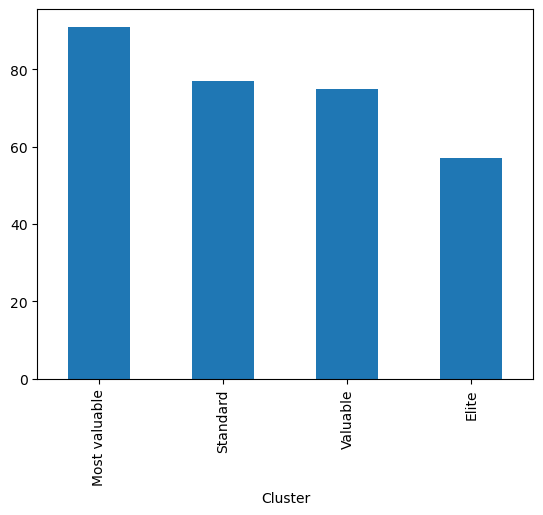

In [57]:
df["Cluster"].value_counts().plot(kind="bar");

In [58]:
new_df=df[df["Cluster"]=="Most valuable"]
new_df

,User_ID,Age,Daily_Time_Spent_Minutes,Posts_Per_Month,Likes_Per_Day,Comments_Per_Day,Followers_Count,Following_Count,Cluster,PCA1,PCA2
2,3,46,139,34,387,164,17821,4731,Most valuable,2.044822,1.271887
6,7,46,169,58,329,77,2156,621,Most valuable,0.908738,-1.476403
9,10,43,212,52,471,131,19202,2134,Most valuable,1.265988,-0.357209
12,13,28,264,56,261,88,12858,4629,Most valuable,0.145654,-0.449040
14,15,41,107,44,449,39,4083,4876,Most valuable,1.687550,0.547234
...,...,...,...,...,...,...,...,...,...,...,...
289,290,41,28,56,319,147,18837,3228,Most valuable,1.895448,0.883128
291,292,44,109,32,59,129,344,2262,Most valuable,0.628216,-0.070476
292,293,34,242,23,319,194,10227,2402,Most valuable,0.665290,-0.761850
296,297,39,215,54,360,4,7059,2253,Most valuable,0.024846,-0.683576


In [59]:
new_df.shape

(91, 11)

In [62]:
import os
os.getcwd()

'C:\\Users\\Lenovo\\Desktop\\ML'

In [64]:
df.to_csv(r'C:\Users\Lenovo\Desktop\ML\Social_Media_user_Segmentaion.csv', index=False)